### Track linear nonlinear delta in good sessions

In [1]:
# import alles
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np
from one.api import ONE
from brainbox.population.decode import get_spike_counts_in_bins
from brainbox.io.one import SpikeSortingLoader, SessionLoader
from brainbox.ephys_plots import plot_brain_regions
from iblatlas.atlas import AllenAtlas
from brainwidemap import bwm_query, load_good_units, load_trials_and_mask, bwm_units
from brainwidemap.bwm_loading import merge_probes
from brainbox.behavior.training import compute_performance, plot_psychometric, plot_reaction_time
from brainbox.task.trials import find_trial_ids
from brainbox.io.one import SessionLoader
from pathlib import Path
from brainbox.task.trials import get_event_aligned_raster, get_psth
from brainbox.singlecell import bin_spikes2D
import numpy as np
from iblatlas.atlas import BrainRegions
from matplotlib import pyplot as plt
import seaborn as sns
import pandas as pd
import itertools
import pickle as pkl
from tqdm import tqdm
from pathlib import Path
import warnings
from sklearn.ensemble import RandomForestClassifier
from ibl_info.prepare_data_pid import (
    cleaned_regions_flags,
    get_new_cinc_intervals,
    prepare_ephys_data,
)
from ibl_info.utils import (
    alternate_discretize,
    compute_mutual_information,
    compute_pid,
    compute_trivariate_mi,
    FIRING_RATE,
    discretize,
    discretize_keeping_zeros,
    equipopulated_binning,
)
import os
import concurrent.futures
import functools
import random
from ibl_info.utils import check_config

In [2]:
with open(
    "../data/generated/decoded/good_decoding_sessions/selective_decomposition_VISp_stim_decoder_good_decoder_sessions_only.pkl",
    "rb",
) as f:
    visp_data = pkl.load(f)

In [6]:
congruent_deltas = []
incongruent_deltas = []
for eids in visp_data.keys():
    congruent_deltas.append(np.mean(visp_data[eids]["congruent_delta"], axis=0))
    incongruent_deltas.append(visp_data[eids]["incongruent_delta"])

In [7]:
congruent_deltas = np.array(congruent_deltas)
incongruent_deltas = np.array(incongruent_deltas)

In [10]:
congruent_deltas.shape

(15, 3)

In [11]:
incongruent_deltas.shape

(15, 3)

In [23]:
all_data = np.hstack((congruent_deltas[:, 0:2], incongruent_deltas[:, 0:2]))

In [53]:
plt.style.use("ggplot")

<BarContainer object of 2 artists>

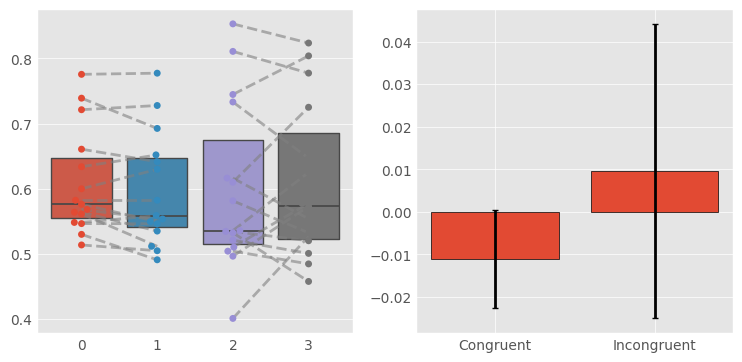

In [74]:
fig, ax = plt.subplots(1, 2, figsize=(8, 4))

sns.boxenplot(all_data, showfliers=False, ax=ax[0])
sns.swarmplot(all_data, ax=ax[0])

for idx in range(len(all_data)):
    ax[0].plot(
        [0, 1], [all_data[idx, 0], all_data[idx, 1]], color="gray", linestyle="--", alpha=0.6
    )
    ax[0].plot(
        [2, 3], [all_data[idx, 2], all_data[idx, 3]], color="gray", linestyle="--", alpha=0.6
    )

ax[1].bar(
    np.arange(2),
    [np.mean(congruent_deltas[:, -1]), np.mean(incongruent_deltas[:, -1])],
    tick_label=["Congruent", "Incongruent"],
    edgecolor="k",
    yerr=[np.std(congruent_deltas[:, -1] / 2), np.std(incongruent_deltas[:, -1] / 2)],
    capsize=2,
)

<Axes: ylabel='Density'>

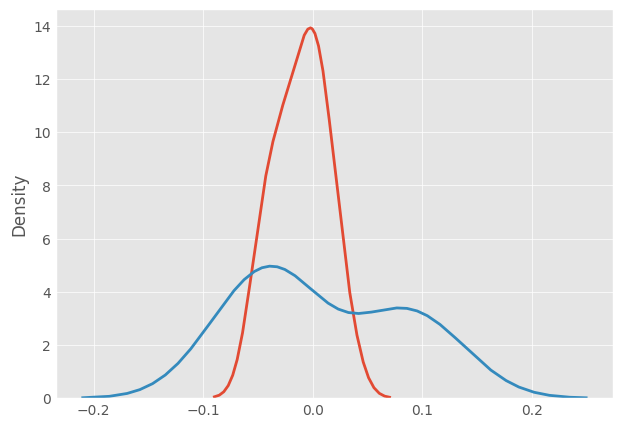

In [78]:
sns.kdeplot(congruent_deltas[:, -1])
sns.kdeplot(incongruent_deltas[:, -1])